# Week 1 - Exploratory Data Analysis (EDA)
**Project:** Sentiment Analysis of myBCA Mobile Banking App Reviews  
**Author:** Elvia Aptanisa  
**Week:** 1  
**Purpose:** Understand the dataset before building the model, analyze label distribution, review length, duplicate entries, and most common words.


## Step 1 - Install & Import Library

In [59]:
!pip install wordcloud

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 - Load Dataset

In [60]:
df = pd.read_csv('mybca_reviews.csv')

print(f" Dataset loaded successfully!")
print(f"Total reviews : {len(df)}")
print(f"Columns       : {list(df.columns)}")
print(f"\nPreview (5 rows):")
print(df.head())

 Dataset loaded successfully!
Total reviews : 5000
Columns       : ['review', 'rating', 'sentiment']

Preview (5 rows):
                                              review  rating sentiment
0                                              bagus       5  Positive
1                                                 ok       5  Positive
2  ko skrg gak ad notifikasi uang masuk y dari ak...       5  Positive
3                                               asik       5  Positive
4  BCA ID ku keblokir terus ke apa sih! dari Janu...       1  Negative


## Step 3 - Label Distribution

Label Distribution:
sentiment
Negative    2452
Positive    2104
Neutral      444
Name: count, dtype: int64

Percentage:
sentiment
Negative    49.0
Positive    42.1
Neutral      8.9
Name: count, dtype: float64


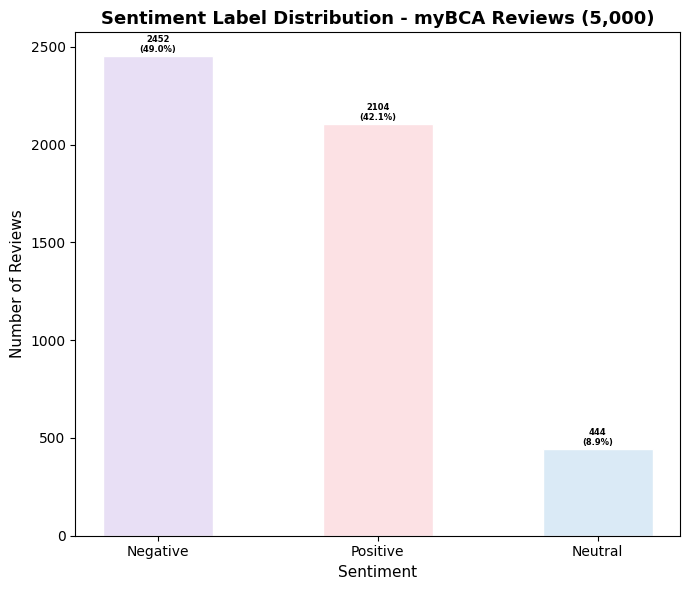

In [61]:
label_counts = df['sentiment'].value_counts()

print("Label Distribution:")
print(label_counts)
print(f"\nPercentage:")
print(round(label_counts / len(df) * 100, 1))

colors = ['#e8dff5','#fce1e4','#daeaf6']
plt.figure(figsize=(7, 6))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, label_counts.values):
    pct = val / len(df) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=6)

plt.title('Sentiment Label Distribution - myBCA Reviews (5,000)', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment', fontsize=11)
plt.ylabel('Number of Reviews', fontsize=11)
plt.tight_layout()
plt.savefig('eda_label_distribution.png', dpi=150)
plt.show()

## Step 4 - Data Quality Check

In [62]:
print("DATA QUALITY CHECK")
print(f"Total reviews     : {len(df)}")
print(f"Missing values    : {df['review'].isnull().sum()}")
print(f"Duplicate reviews : {df['review'].duplicated().sum()}")
print(f"\nShortest review   : '{df.loc[df['review'].str.len().idxmin(), 'review']}'")
print(f"Longest review    : {df['review'].str.len().max()} characters")
print(f"Average length    : {df['review'].str.len().mean():.0f} characters")

DATA QUALITY CHECK
Total reviews     : 5000
Missing values    : 0
Duplicate reviews : 718

Shortest review   : '👍'
Longest review    : 500 characters
Average length    : 83 characters


## Step 5 - Review Length Distribution

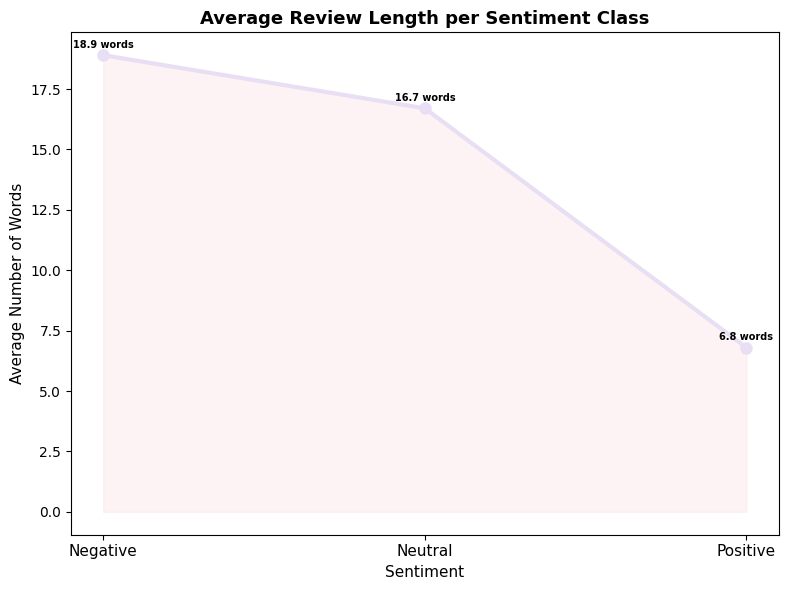

In [63]:
df['review_length'] = df['review'].astype(str).apply(lambda x: len(x.split()))
avg_length = df.groupby('sentiment')['review_length'].mean().round(1)

plt.figure(figsize=(8, 6))
plt.fill_between(range(len(avg_length)), avg_length.values, color='#fce1e4', alpha=0.4)
plt.plot(range(len(avg_length)), avg_length.values, color='#e8dff5', linewidth=3, marker='o', markersize=8)

for i, (label, val) in enumerate(zip(avg_length.index, avg_length.values)):
    plt.text(i, val + 0.3, f'{val} words', ha='center', fontweight='bold', fontsize=7)

plt.xticks(range(len(avg_length)), avg_length.index, fontsize=11)
plt.title('Average Review Length per Sentiment Class', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment', fontsize=11)
plt.ylabel('Average Number of Words', fontsize=11)
plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=150)
plt.show()

## Step 6 - WordCloud per Sentiment Class

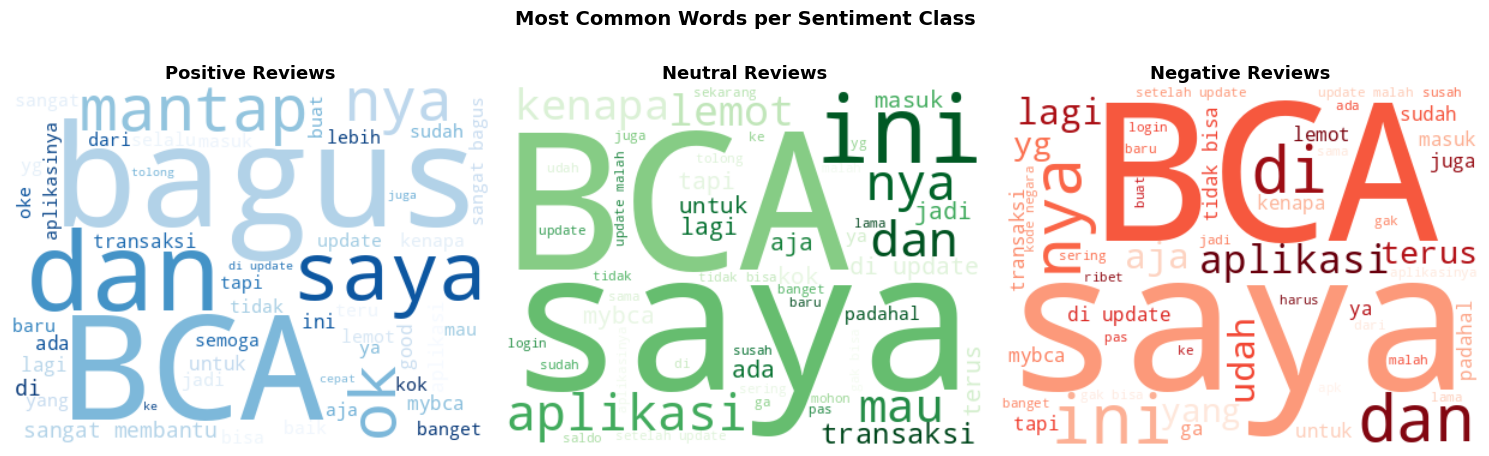

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sentiments = ['Positive', 'Neutral', 'Negative']
colors_wc = ['Blues', 'Greens', 'Reds']

for ax, sentiment, colormap in zip(axes, sentiments, colors_wc):
    text = ' '.join(df[df['sentiment'] == sentiment]['review'].astype(str).tolist())

    wordcloud = WordCloud(
        width=400,
        height=300,
        background_color='white',
        colormap=colormap,
        max_words=50
    ).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'{sentiment} Reviews', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Most Common Words per Sentiment Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_wordcloud.png', dpi=150)
plt.show()